# Project -1 House Price Prediction

### Task -1 Data Loading and Exploration

In [105]:
#Import library & Load Dataset

import pandas as pd
df = pd.read_csv("Housing.csv")
df.head(10)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


In [106]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [107]:
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [108]:
#No. of rows and columns

print("Rows and Columns:")
print(df.shape)

Rows and Columns:
(545, 13)


In [109]:
#Feature and Target Variable

X = df.drop("price", axis=1)
y = df["price"]

print("Features:")
print(X.columns)

print("\nTarget:")
print(y.name)

Features:
Index(['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom',
       'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea',
       'furnishingstatus'],
      dtype='object')

Target:
price


In [110]:
#Removing null values
df.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

### Task -2 - Data CLeaning 

In [111]:
#Removing duplicates

print("No missing values found.")
df = df.drop_duplicates()
print("Duplicates removed")

No missing values found.
Duplicates removed


In [112]:
#Numerical Columns

numeric_cols = df.select_dtypes(include=['int64','float64']).columns
for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())


In [113]:
#Categorical Columns

for col in df.select_dtypes(include='object'):
    df[col] = df[col].fillna(df[col].mode()[0])

In [114]:
#One-Hot Encding

df = pd.get_dummies(df, drop_first=True)
print(df.head())

      price  area  bedrooms  bathrooms  stories  parking  mainroad_yes  \
0  13300000  7420         4          2        3        2          True   
1  12250000  8960         4          4        4        3          True   
2  12250000  9960         3          2        2        2          True   
3  12215000  7500         4          2        2        3          True   
4  11410000  7420         4          1        2        2          True   

   guestroom_yes  basement_yes  hotwaterheating_yes  airconditioning_yes  \
0          False         False                False                 True   
1          False         False                False                 True   
2          False          True                False                False   
3          False          True                False                 True   
4           True          True                False                 True   

   prefarea_yes  furnishingstatus_semi-furnished  furnishingstatus_unfurnished  
0          True  

### Task -3 Model Building

In [115]:
#Train-Test Split

from sklearn.model_selection import train_test_split

X = df.drop("price", axis=1)
y = df["price"]
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [116]:
#Linear Regression

from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

In [117]:
#Evaluation of model

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
import numpy as np
mae_lr = mean_absolute_error(y_test, lr_pred)
mse_lr = mean_squared_error(y_test, lr_pred)

rmse_lr = np.sqrt(mse_lr)

r2_lr = r2_score(y_test, lr_pred)
print(mae_lr)
print(rmse_lr)
print(r2_lr)

970043.4039201637
1324506.9600914388
0.6529242642153184


In [118]:
#Random Forest Regressor

from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

In [119]:
#Evaluation of Random Forest

mae_rf = mean_absolute_error(y_test, rf_pred)
mse_rf = mean_squared_error(y_test, rf_pred)

rmse_rf = np.sqrt(mse_rf)

r2_rf = r2_score(y_test, rf_pred)

print(mae_rf)
print(rmse_rf)
print(r2_rf)

1013968.579587156
1398115.6668385956
0.6132752494107068


In [120]:
#Comparing models

comparison = pd.DataFrame({
    "Model":["Linear Regression","Random Forest"],
    "MAE":[mae_lr, mae_rf],
    "RMSE":[rmse_lr, rmse_rf],
    "R2 Score":[r2_lr, r2_rf]
})
comparison

,Model,MAE,RMSE,R2 Score
0,Linear Regression,9.700434e+05,1.324507e+06,0.652924
1,Random Forest,1.013969e+06,1.398116e+06,0.613275


### Task -4 Data Visualization

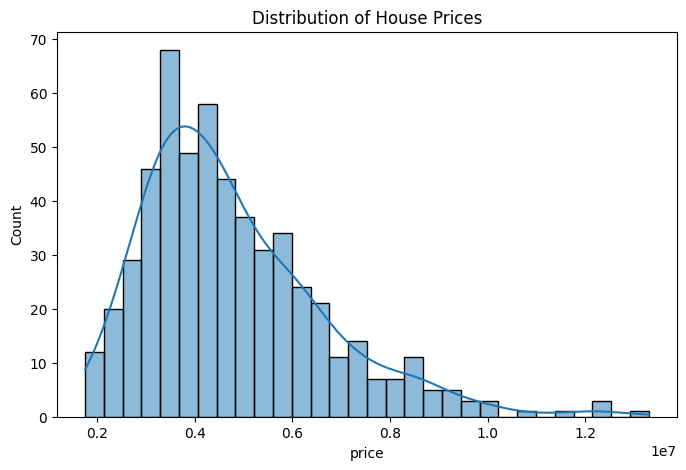

In [121]:
#Price Distribution

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.histplot(
    df["price"],
    bins=30,
    kde=True
)
plt.title("Distribution of House Prices")
plt.savefig("charts/price_distribution.png")
plt.show()

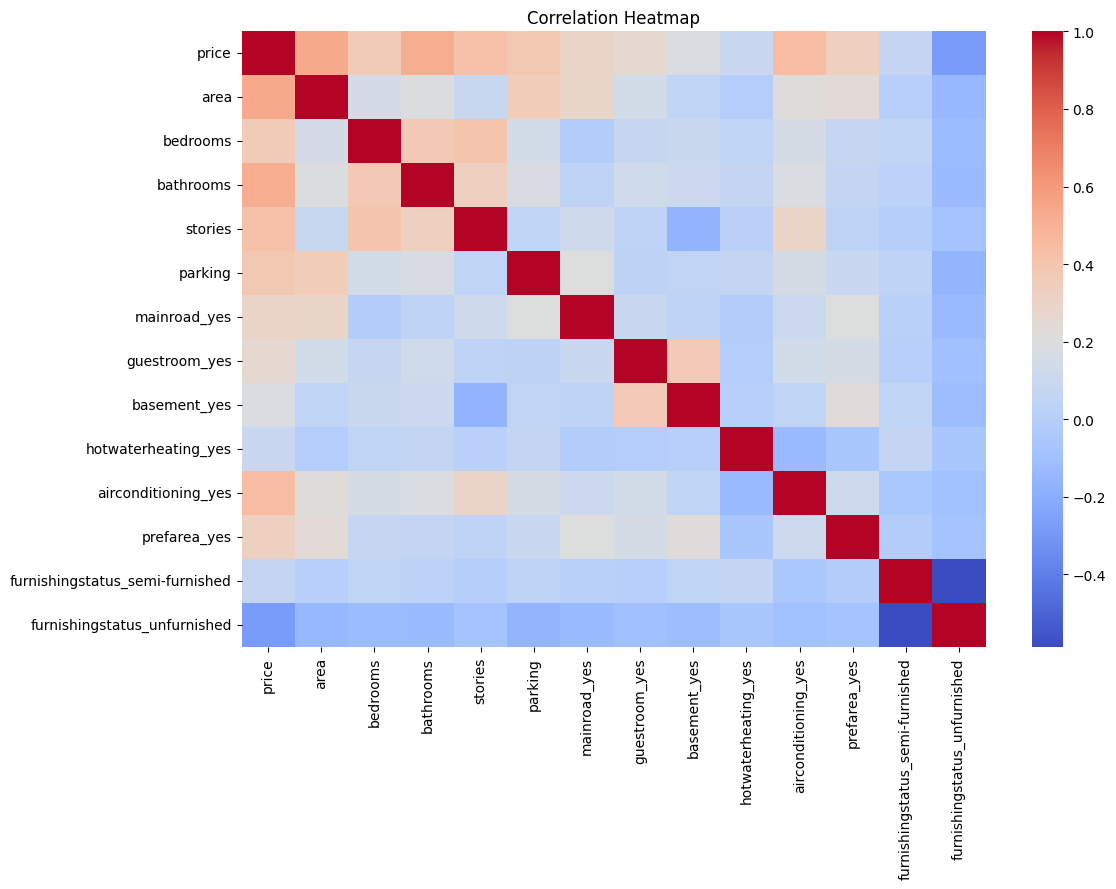

In [122]:
#Coreelation heatmap

plt.figure(figsize=(12,8))
sns.heatmap(
    df.corr(),
    cmap="coolwarm"
)
plt.title("Correlation Heatmap")
plt.savefig("charts/correlation_heatmap.png")
plt.show()

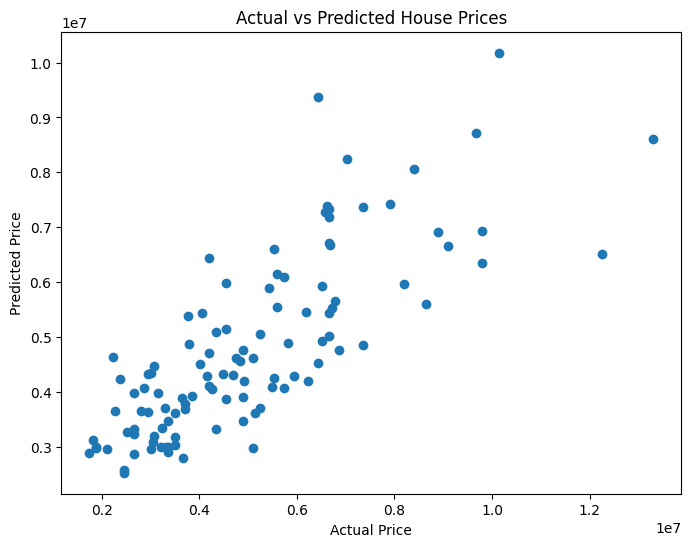

In [123]:
#Actucal vs Predicted

plt.figure(figsize=(8,6))
plt.scatter(
    y_test,
    rf_pred
)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted House Prices")
plt.savefig("charts/actual_vs_predicted.png")
plt.show()

In [124]:
#Feature Importance

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})
importance = importance.sort_values(
    by="Importance",
    ascending=False
)
importance.head(10)

,Feature,Importance
0,area,0.468535
2,bathrooms,0.152554
9,airconditioning_yes,0.060238
4,parking,0.057273
3,stories,0.057064
1,bedrooms,0.047370
12,furnishingstatus_unfurnished,0.036972
7,basement_yes,0.032176
10,prefarea_yes,0.028432
8,hotwaterheating_yes,0.018305


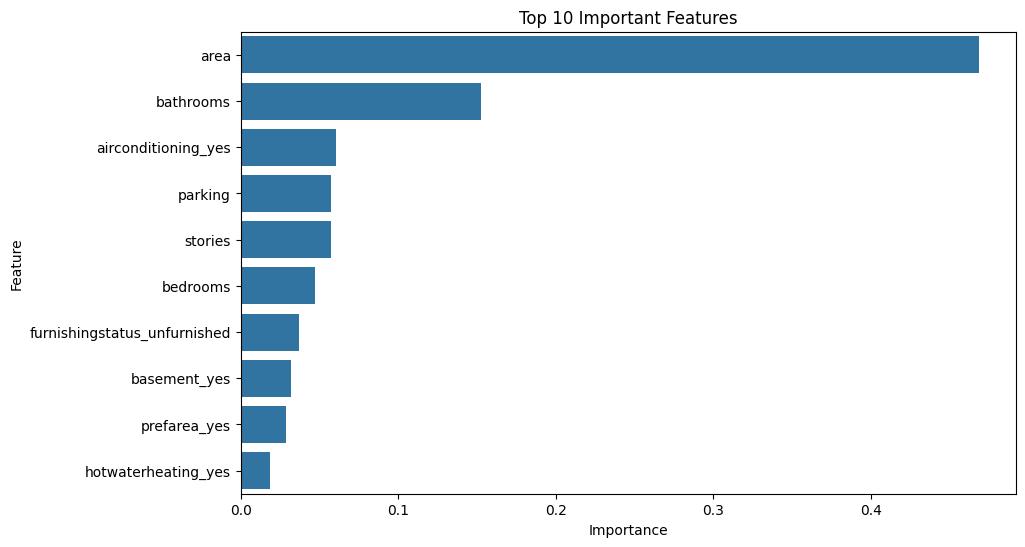

In [125]:
#Feature Importance chart

plt.figure(figsize=(10,6))
sns.barplot(
    data=importance.head(10),
    x="Importance",
    y="Feature"
)
plt.title("Top 10 Important Features")
plt.show()

### Task -5 Insights & Summary

## Summary Paragraph
The analysis revealed that features such as area, number of bathrooms, parking availability, air conditioning, and location-related factors had the strongest influence on house prices. Among the models tested, Linear Regression performed better than Random Forest, achieving an R² score of approximately 0.65, which means the model was able to explain about 65% of the variation in house prices. The prediction errors were reasonable considering the limited number of features available in the dataset. One surprising observation was that amenities such as air conditioning and preferred area had a noticeable impact on property prices in addition to house size. Based on these findings, real estate businesses should focus on highlighting property size, location advantages, and key amenities when pricing and marketing homes, as these factors significantly affect market value.



In [126]:
#Best-Model Comparision

best_model = comparison.loc[
    comparison["R2 Score"].idxmax()
]

print("Best Model:")
print(best_model)
print("Linear Regression selected as final model.")

Best Model:
Model       Linear Regression
MAE              970043.40392
RMSE           1324506.960091
R2 Score             0.652924
Name: 0, dtype: object
Linear Regression selected as final model.
